In [4]:
from graph_transformer_long_range_niches.tl import pad_batch
from graph_transformer_long_range_niches._paths import CFG_FILES, RESULTS, COSMX_PANCREAS, COSMX_PANCREAS_S1, FIG_PATH
from graph_transformer_long_range_niches.model.gnn_transformer import LitGNNTransformer
from graph_transformer_long_range_niches.pl import CustomColormap, plot_attention_sender_receiver, plot_attention_sender_receiver, SelfAttentionRelevance, calculate_attention, normalized_attention, normalized_class_attention
from graph_transformer_long_range_niches.pp import prepare_geome_dataset, split_adata
from graph_transformer_long_range_niches.config import load_config

import warnings
warnings.filterwarnings("ignore")

from torch_geometric.loader import DataLoader

from pathlib import Path
import wandb
import torch
import os

## plotting
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import pickle

import scanpy as sc
import squidpy as sq

from sklearn.preprocessing import MinMaxScaler

In [29]:
FIG_RESULTS = Path(FIG_PATH, 'cosmx_pancreas', 'figures')
FIG_RESULTS

PosixPath('/home/icb/francesca.drummer/1-Projects/GT-long-range-niches/figures/cosmx_pancreas/figures')

# Evaluation: Pancreas CosmX data

In this notebook we explore the performance of InterScale on cell-level tasks:

1. Cell type x Cell type interaction strength
2. Spatial observation of cell-to-cell interactions

In [6]:
def load_model(PATH, model_type = "gnn-transformer"):
    model_transformer_ckpt = torch.load(Path(RESULTS, FOLDER, f"{PATH}_{model_type}.ckpt"))
    cfg = model_transformer_ckpt['hyper_parameters']['cfg']
    model_transformer = LitGNNTransformer(cfg)
    model_transformer.load_state_dict(model_transformer_ckpt['state_dict'])
    obs_csv = pd.read_csv(Path(RESULTS, FOLDER, f"{PATH}_obs.csv"))
    obs_csv = obs_csv.rename(columns={'Unnamed: 0': 'obs_names'})
    return model_transformer, cfg, obs_csv

## Load model and data

In [38]:
FOLDER = "cosmx_pancreas"
CONDITION_DATA = "pancreas_condition_sliding_window_3_2_40"
CELLTYPE_DATA = "pancreas_cell_type_coarse_sliding_window_1_44"
GEX_DATA = "pancreas_None_sliding_window_3_2_44"

In [39]:
model_transformer_condition, cfg_condition, obs_condition = load_model(CONDITION_DATA, model_type = "gnn-transformer")
#model_transformer_ct, cfg_ct, obs_ct = load_model(CELLTYPE_DATA, model_type = "gnn-transformer")
#model_transformer_gex, cfg_gex, obs_gex = load_model(GEX_DATA, model_type = "gnn-transformer")

In [40]:
cfg_condition.set_new_allowed(True)
cfg_condition.defrost()
cfg_condition.dataset.split_key = 'split'
#cfg.dataset.spatial_neigbors_kwargs.radius = 0
cfg_condition.freeze()

In [41]:
cfg_condition

CfgNode({'wandb': CfgNode({'use': True, 'project_name': 'GTLongRange_CosmXPancreas'}), 'model': CfgNode({'model_type': 'gnn-transformer', 'n_epochs': 10, 'save': 'local', 'output_path': '/lustre/groups/ml01/projects/2024_spatial_long_range_GT_francesca.drummer/results/cosmx_pancreas/', 'decoder': CfgNode({'type': 'nonlinear', 'hidden_dims': [256, 128], 'dropout': 0.1})}), 'optim': CfgNode({'lr': 0.005, 'wd': 0.0, 'warm_up': 40, 'loss': 'CrossEntropy', 'seed': 40, 'cross_corr': 'gene'}), 'dataset': CfgNode({'h5ad_data': '/lustre/groups/ml01/projects/2024_spatial_long_range_GT_francesca.drummer/data/cosmx_pancreas.h5ad', 'name': 'pancreas', 'description': "Spatial pancreas data with graphs for each .obs['sliding_window'] and prediction node .obs['niche'].", 'prediction_task': 'graph_classification', 'prediction_obs': 'condition', 'library_key': ['sliding_window_square', 'sliding_window_h', 'sliding_window_v'], 'fine_tuning': [], 'subset_dict': CfgNode({}), 'split_key': 'split', 'obs_spli

In [42]:
adata = sc.read_h5ad(Path(COSMX_PANCREAS))
adata

AnnData object with n_obs × n_vars = 386727 × 979
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.GCG', 'Max.GCG', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'condition', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_NegPrb', 'log1p_total_counts_NegPrb', 'pct_counts_NegPrb', 'n_genes', 'cell_type_coarse', 'CellTypes_max', 'slide_fov', 'slide_condition', 'split', 'split_0', 'split_1', 'split_2', 'globalX', 'globalY', 'sliding_window_square', 'sliding_window_h', 'sliding_window_v'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_fov'
    layers: 'counts'

In [43]:
adata.obs['split'] = np.array(obs_condition['split'].values)

In [44]:
# Creating a DataFrame from 'split', 'fov', and 'condition'
df = adata.obs[['split', 'fov', 'condition']]
value_counts = pd.DataFrame(df.values, columns=df.columns).value_counts()
print(value_counts)

split  fov  condition
train  11   T1D          17404
       9    T1D          17124
       10   T1D          16589
       16   ND           15927
       1    T1D          15720
       3    T1D          15687
       15   ND           15453
       4    T1D          12814
       19   ND           11212
       7    T1D          11161
       20   ND           10762
       12   ND           10714
       18   ND           10595
       5    T1D          10448
val    17   ND           10240
       6    T1D           9809
train  21   ND            8838
       14   ND            7761
val    8    T1D           7360
train  13   T1D           7313
val    25   T1D           7237
train  12   T1D           6840
test   14   T1D           6727
train  21   T1D           6685
val    22   T1D           6656
train  2    T1D           6468
val    2    T1D           6349
       7    T1D           6220
train  6    T1D           6127
val    5    T1D           5703
train  23   ND            5583
test   17   ND   

## Attention cell-level analysis on FOV 12

In [45]:
del sub_adata_12.uns['sliding_window_2_colors']

NameError: name 'sub_adata_12' is not defined

In [ ]:
sq.pl.spatial_scatter(
                sub_adata_12,
                color = ['sliding_window', 'sliding_window_3', 'cell_type_coarse'],
                spatial_key = 'spatial',
                shape=None,
                save=Path(FIG_PATH, 'cosmx_pancreas', 'fov_12_sliding_windows')
    )

In [46]:
import matplotlib.pyplot as plt
import numpy as np
import squidpy as sq
from anndata import AnnData
import pandas as pd

import torch

from graph_transformer_long_range_niches.pp import prepare_geome_dataset
from torch_geometric.loader import DataLoader

from sklearn.preprocessing import MinMaxScaler

class SelfAttentionRelevance:
    """ Chefer, H., Gur, S. & Wolf, L. Generic Attention-model Explainability for Interpreting Bi-Modal and Encoder-Decoder Transformers. 
    Preprint at https://doi.org/10.48550/arXiv.2103.15679 (2021).
    """

    def __init__(self, model):
        """
        Initializes the SelfAttentionRelevance class with a TransformerNodeEncoder.

        Parameters
        ----------
            model: torch.nn.Module
                The model to be used for generating relevance.
        """
        self.model = model

    @staticmethod
    def avg_heads(attn_map, grad):
        """
        Rule 5 from Chefer et al.: Averages the heads in the attention map after applying gradients.

        Parameters
        ----------
            attn_map: Tensor
                Attention weight (Key and Query dependent), shape: BHxSxS
            grad: Tensor
                Gradients to apply to the attention map, shape: BHxSxS

        Returns
        -------
            Tensor
                Averaged attention map after applying gradients.
        """
        attn_map = attn_map.reshape(-1, attn_map.shape[-2], attn_map.shape[-1])
        grad = grad.reshape(-1, grad.shape[-2], grad.shape[-1])
        attn_map = grad * attn_map
        attn_map = attn_map.clamp(min=0).mean(dim=0)
        return attn_map

    @staticmethod
    def apply_self_attention_rules(R_ss, cam_ss):
        """
        Rule 6 from Chefer et al.: Applies self-attention rules to update the relevance score.

        Parameters
        ----------
            R_ss: Tensor
                Relevance score matrix.
            cam_ss: Tensor
                Attention map.

        Returns
        -------
            Tensor
                Updated relevance score matrix.
        """
        return torch.matmul(cam_ss, R_ss)

    def generate_relevance(self, padded_h_node, src_padding_mask, category_index=None):
        """
        Generates the relevance score for a given input and category index.

        Parameters
        ----------
            padded_h_node: Tensor
                Padded input node representations.
            src_padding_mask: Tensor
                Padding mask for the input.
            category_index: List[int], optional
                List of indices to consider in the category mask, default is None.
        """
        output, _ = self.model(padded_h_node, src_padding_mask, register_hook=True)
        category_mask = torch.zeros(output.size())
        if category_index is not None:
            category_mask[category_index, :, :] = 1
        print('Category mask: ', category_mask.shape)
        loss = (output * category_mask).sum()
        self.model.zero_grad()
        loss.backward(retain_graph=True)

        num_tokens = self.model.transformer_encoder.layers[0].get_attn_output().shape[0]
        print(num_tokens)

        #I = torch.eye(num_tokens, num_tokens).cuda()
        I = torch.eye(num_tokens, num_tokens)

        for idx, encoder in enumerate(self.model.transformer_encoder.layers):
            attn_out_weights = encoder.get_attn_output_weights()
            attn_grad = encoder.get_attn_gradients()

            print(f"Layer {idx + 1} attention gradient shape: {attn_grad.shape}")
            print(f"Layer {idx + 1} attention output weights shape: {attn_out_weights.shape}")

            attn_map = self.avg_heads(attn_out_weights, attn_grad)
            print(f"Average attention map shape: {attn_map.shape}")
            print("I: ", I)
            #I += self.apply_self_attention_rules(I.cuda(), attn_map.cuda())
            I += self.apply_self_attention_rules(I, attn_map)
        
        return I

def calculate_attention(adata, cfg, model_transformer, obs_col, class_name, attention_obs=None, attention_class=None, library_key=None, split_key = 'split'):
    """
    Parameters
    ----------
        adata: AnnData
        obs_metadata: pandas.Dataframe
            .obs metadata from object of interest
        obs_col: str
            Name of annotation column in .obs where the observation used as classes to 
        class_name: str 
            Name of class in .obs[obs_col] that we are interested in plotting the attention for
        attention_class: str
            If None, all classes in attention_obs are considered
        library_key: Optional[str]
    """
    self_attention_relevance = SelfAttentionRelevance(model_transformer.transformer_encoder)
    
    # subset relevant data
    sub_adata = adata[adata.obs[obs_col] == class_name]
    assert split_key in adata.obs

    cfg.set_new_allowed(True)
    cfg.defrost()
    cfg.dataset.library_key = [library_key]
    cfg.freeze()

    if library_key:  
        assert library_key in sub_adata.obs
        cfg.set_new_allowed(True)
        cfg.defrost()
        cfg.dataset.library_key = [library_key]
        cfg.freeze()
        library_key_list = np.unique(sub_adata.obs[library_key])
    else: 
        library_key_list = [None]
    print(library_key_list)
    
    # load PyG objects for evaluation
    pyg_datas, _ = prepare_geome_dataset(sub_adata, cfg, split_key=split_key) # datas = [datas_train, datas_test]
    datas = [pyg for datas in pyg_datas for pyg in datas]
    data_loader = DataLoader(datas)
    
    sub_adata.obs['cls'] = np.nan
    attention_matrix_dict = {}
    transformer_in_dict = {}
    transformer_out_dict = {}

    
    for batch, library_id in zip(data_loader, library_key_list):
        print('batch: ', batch, 'library_id', library_id)
        transformer_in, transformer_out, src_padding_mask, index_nodes, dec_out = model_transformer.evaluation(batch)
        if not attention_obs:
            attention_index = np.arange(0, len(index_nodes))
        I = self_attention_relevance.generate_relevance(transformer_in, src_padding_mask, category_index=attention_index)
        cls = I[:1, 1:].cpu().detach().numpy() 
        print('cls', len(cls[0]))
        # Create a pandas DataFrame for the attention matrix with obs_names as row and column indices
        if library_key:
            library_mask = (sub_adata.obs[library_key] == library_id)
            library_indices = sub_adata.obs[library_mask].index
            print('library_mask: ', len(library_mask), ' library_indices: ' , len(library_indices), ' index_nodes :', len(index_nodes[0]))
            
            # Then, use these indices to select only the ones in index_nodes[0]
            final_indices = library_indices[index_nodes[0]]
            
            # Now assign the values using these indices
            sub_adata.obs.loc[final_indices, 'cls'] = cls[0]
            attention_matrix_df = pd.DataFrame(
                I[1:, 1:].cpu().detach().numpy(),
                # index=sub_adata.obs_names[sub_adata.obs[library_key]==library_id][index_nodes[0]],
                # columns=sub_adata.obs_names[sub_adata.obs[library_key]==library_id][index_nodes[0]]
                index = final_indices,
                columns = final_indices
            )
        else:
            sub_adata.obs['cls'][sub_adata.obs_names[index_nodes[0]]] = cls[0] # TODO change
            attention_matrix_df = pd.DataFrame(
                I[1:, 1:].cpu().detach().numpy(),
                index=sub_adata.obs_names[index_nodes[0]],
                columns=sub_adata.obs_names[index_nodes[0]]
            )
        attention_matrix_dict[str(library_id)] = attention_matrix_df
        transformer_in_dict[str(library_id)] = transformer_in
        transformer_out_dict[str(library_id)] = transformer_out
        
    return sub_adata, attention_matrix_dict, transformer_in_dict, transformer_out_dict, dec_out

## Graph label: Condition prediction

In [47]:
# T1D
sub_adata_1_12_1_T1D, attention_matrix_dict_condition_12, trans_in_dict_cond_12, trans_out_dict_cond_12, dec_out_12 = calculate_attention(adata, cfg_condition, model_transformer_condition, obs_col = 'slide_fov', class_name = '1_12', library_key='sliding_window_square')
sub_adata_1_12_2_T1D, _, _, _, _ = calculate_attention(adata, cfg_condition, model_transformer_condition, obs_col = 'slide_fov', class_name = '1_12', library_key='sliding_window_h')
sub_adata_1_12_3_T1D, _, _, _, _ = calculate_attention(adata, cfg_condition, model_transformer_condition, obs_col = 'slide_fov', class_name = '1_12', library_key='sliding_window_v')

# No Diabetes
sub_adata_1_22_1_ND, _, _, _, _ = calculate_attention(adata, cfg_condition, model_transformer_condition, obs_col = 'slide_fov', class_name = '1_22', library_key='sliding_window_square')
sub_adata_1_22_2_ND, _, _, _, _ = calculate_attention(adata, cfg_condition, model_transformer_condition, obs_col = 'slide_fov', class_name = '1_22', library_key='sliding_window_h')
sub_adata_1_22_3_ND, _, _, _, _ = calculate_attention(adata, cfg_condition, model_transformer_condition, obs_col = 'slide_fov', class_name = '1_22', library_key='sliding_window_v')

#sub_adata_2_12, attention_matrix_dict_condition_12, trans_in_dict_cond_12, trans_out_dict_cond_12, dec_out_12 = calculate_attention(adata, cfg_condition, model_transformer_condition, obs_col = 'slide_fov', class_name = '2_12', library_key='sliding_window_1')
#sub_adata_3_12, attention_matrix_dict_condition_12, trans_in_dict_cond_12, trans_out_dict_cond_12, dec_out_12 = calculate_attention(adata, cfg_condition, model_transformer_condition, obs_col = 'slide_fov', class_name = '3_12', library_key='sliding_window_1')

#sub_adata_10, attention_matrix_dict_condition_10, _, _, _ = calculate_attention(adata, cfg_condition, model_transformer_condition, obs_col = 'fov', class_name = '10', library_key='sliding_window')

['1_12_window_1' '1_12_window_2' '1_12_window_4' '1_12_window_5'
 '1_12_window_7' '1_12_window_8']
Split key split already exists in adata.obs
coord_type: generic
library_key: sliding_window_square
n_neighs: 6
radius: 30
call new
{'condition': ['ND']}
call new
{'condition': []}
batch:  DataBatch(x=[934, 979], edge_index=[2, 82], y=[934, 1], obs_names=[934], batch=[934], ptr=[2]) library_id 1_12_window_1
Category mask:  torch.Size([935, 1, 32])
935
Layer 1 attention gradient shape: torch.Size([4, 935, 935])
Layer 1 attention output weights shape: torch.Size([4, 935, 935])
Average attention map shape: torch.Size([935, 935])
I:  tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 1., 0., 0.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.]])
Layer 2 attention gradient shape: torch.Size([4, 935, 935])
Layer 2 attention output weights shape: torch.Size([

IndexError: index 268 is out of bounds for axis 0 with size 268

In [32]:
dec_out_12

tensor([[-5.4338,  4.8081]], grad_fn=<AddmmBackward0>)

### CLS token

                  mean_cls_1_12_window_1
cell_type_coarse                        
Mast                            0.625156
Beta                            0.056512
Immune                         -0.020928
Endothelial                    -0.163659
Ductal                         -0.225355
Fibroblasts                    -0.241477
Acinar                         -0.263103
Endocrine                      -0.585763
Alpha                          -0.647061
                  mean_cls_1_12_window_2
cell_type_coarse                        
Endocrine                       0.999994
Mast                            0.999994
Endothelial                     0.564770
Immune                          0.166734
Acinar                          0.049954
Ductal                          0.033781
Fibroblasts                    -0.054282
                  mean_cls_1_12_window_4
cell_type_coarse                        
Acinar                          0.119324
Endocrine                       0.101015
Fibroblasts     

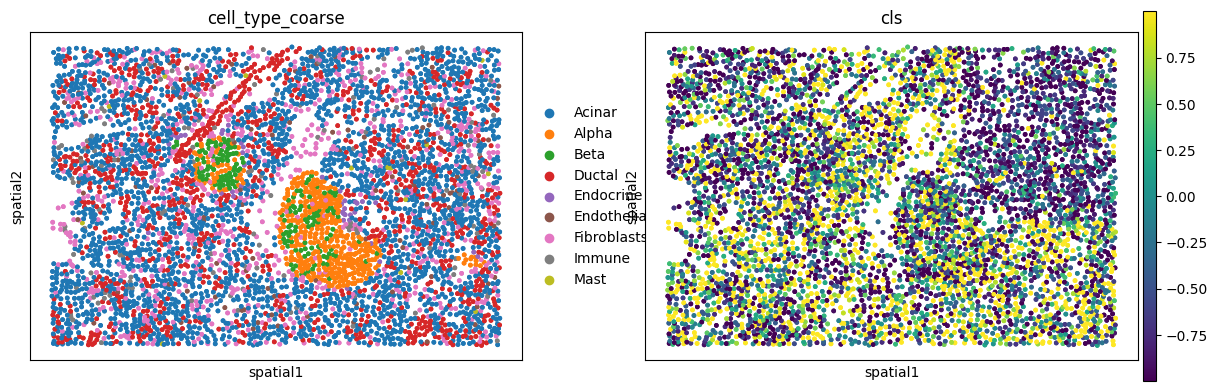

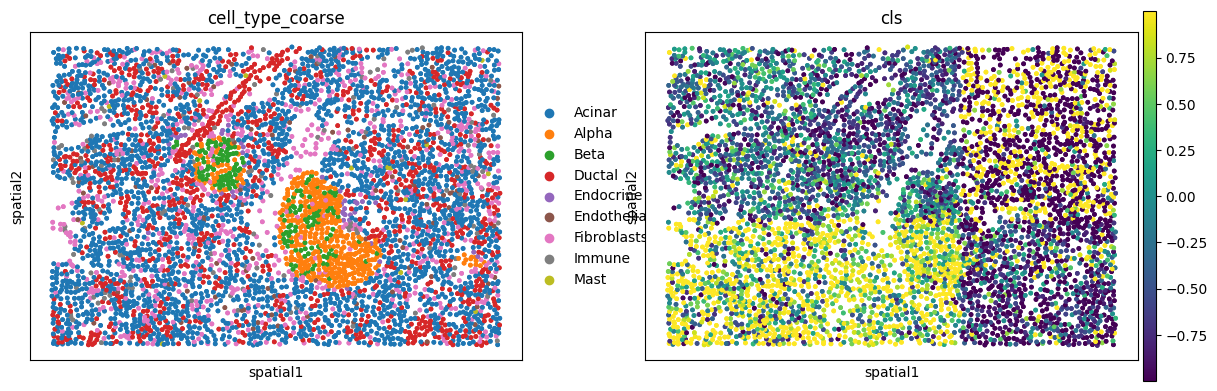

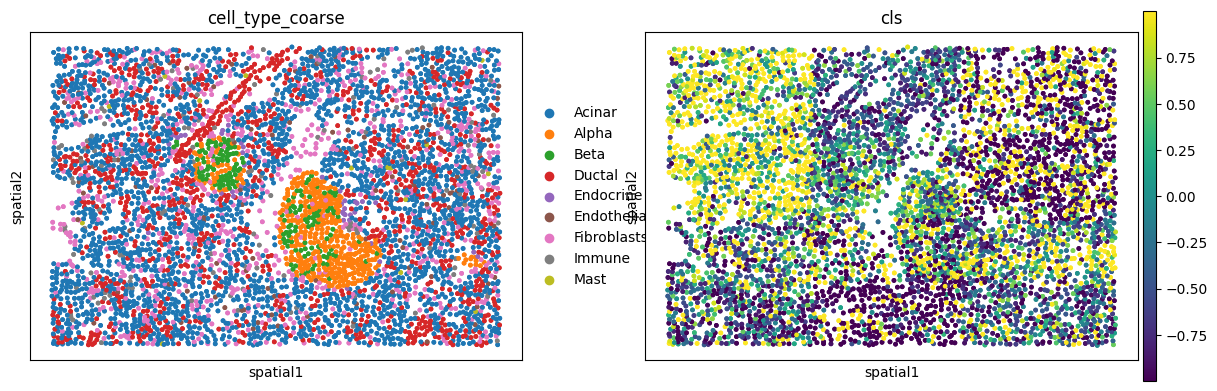

In [54]:
cell_type_key = 'cell_type_coarse'
T1D_list = [(sub_adata_1_12_1_T1D,'sliding_window_square'), (sub_adata_1_12_2_T1D ,'sliding_window_h'), (sub_adata_1_12_3_T1D, 'sliding_window_v')]
#ND_list = [(sub_adata_1_22_1,'sliding_window_1'), (sub_adata_1_22_2 ,'sliding_window_2'), (sub_adata_1_22_3, 'sliding_window_3')]
ND_list = []

for sw_list in [T1D_list, ND_list]:
    for sub_adata, sliding_window_key in sw_list:
        #, sub_adata_1_22_1, sub_adata_1_22_2, sub_adata_1_22_3
        scores = torch.Tensor(sub_adata.obs['cls'])
        clamp = 0.2
        if clamp:
            q05, q95 = torch.quantile(scores, clamp), torch.quantile(scores, 1-clamp)
            scores = np.clip(scores, a_min=q05, a_max=q95)
        
        # Normalize scores
        #scores = MinMaxScaler(feature_range=(-1, 1)).fit_transform(scores.reshape(-1, 1))
        sub_adata.obs['cls'] = scores.flatten()
    
        all_stats_df = pd.DataFrame()
        for sw_id in np.unique(sub_adata.obs[sliding_window_key]):
            sub_sub_data = sub_adata[sub_adata.obs[sliding_window_key] == sw_id]
            
            stats_df = sub_sub_data.obs.groupby(cell_type_key).agg(
                mean_cls=('cls', 'mean')            
            )
            
            # Rank cell types by mean cls score
            stats_df = stats_df.sort_values(by='mean_cls', ascending=False)
        
            # Rename columns to include the sw_id for later merging
            stats_df = stats_df.rename(columns={'mean_cls': f'mean_cls_{sw_id}'})

            print(stats_df)
        
            # Merge with the main dataframe
            all_stats_df = all_stats_df.join(stats_df, how='outer')
            
        print(all_stats_df)

        stats_df = sub_sub_data.obs.groupby(sliding_window_key).agg(
                mean_cls=('cls', 'mean')            
            )
        print(stats_df)
    
        # Visualization
        sq.pl.spatial_scatter(
            sub_adata,
            color=[cell_type_key, 'cls'],
            spatial_key='spatial',
            shape=None,
            library_key='slide_fov',
            save = f'{FIG_RESULTS}/condition/CLS_{sliding_window_key}'
        )

## Node label prediction

In [99]:
# _, attention_matrix_dict_ct_12 = calculate_attention(adata, cfg_ct, model_transformer_ct, obs_col = 'fov', class_name = '12', library_key='sliding_window')
# _, attention_matrix_dict_ct_10 = calculate_attention(adata, cfg_ct, model_transformer_ct, obs_col = 'fov', class_name = '10', library_key='sliding_window')

call new
{'cell_type_coarse': ['Acinar', 'Alpha', 'Beta', 'Ductal', 'Endocrine', 'Endothelial', 'Fibroblasts', 'Immune', 'Mast']}
call new
{'cell_type_coarse': []}
DataBatch(x=[1035, 979], edge_index=[2, 1266], y=[1035, 9], obs_names=[1035], batch=[1035], ptr=[2]) 12_0
Category mask:  torch.Size([1001, 1, 128])
1001
Layer 1 attention gradient shape: torch.Size([4, 1001, 1001])
Layer 1 attention output weights shape: torch.Size([4, 1001, 1001])
Average attention map shape: torch.Size([1001, 1001])
I:  tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 1., 0., 0.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.]])
Layer 2 attention gradient shape: torch.Size([4, 1001, 1001])
Layer 2 attention output weights shape: torch.Size([4, 1001, 1001])
Average attention map shape: torch.Size([1001, 1001])
I:  tensor([[1.0000e+00, 2.6802e-05, 3.7247e-05,  ..., 0

In [31]:
path = Path(RESULTS, FOLDER, "FOV_12")
print(path)

/lustre/groups/ml01/projects/2024_spatial_long_range_GT_francesca.drummer/results/cosmx_pancreas/FOV_12


In [30]:
_, attention_matrix_dict_gex_12, transformer_in_dict_gex_12, transformer_out_dict_gex_12, _ = calculate_attention(adata, cfg_gex, model_transformer_gex, obs_col = 'fov', class_name = '12', library_key='sliding_window')
_, attention_matrix_dict_gex_10, transformer_in_dict_gex_10, transformer_out_dict_gex_10, _ = calculate_attention(adata, cfg_gex, model_transformer_gex, obs_col = 'fov', class_name = '10', library_key='sliding_window')

call new
call new
call new
call new
DataBatch(x=[1035, 979], edge_index=[2, 1266], obs_names=[1035], batch=[1035], ptr=[2]) 12_0
Category mask:  torch.Size([1036, 1, 128])
1036
Layer 1 attention gradient shape: torch.Size([4, 1036, 1036])
Layer 1 attention output weights shape: torch.Size([4, 1036, 1036])
Average attention map shape: torch.Size([1036, 1036])
I:  tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 1., 0., 0.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.]])
Layer 2 attention gradient shape: torch.Size([4, 1036, 1036])
Layer 2 attention output weights shape: torch.Size([4, 1036, 1036])
Average attention map shape: torch.Size([1036, 1036])
I:  tensor([[1.0000e+00, 4.6320e-05, 2.3828e-05,  ..., 5.2583e-05, 4.4004e-05,
         7.3396e-05],
        [2.1025e-08, 1.0000e+00, 5.1770e-09,  ..., 9.5478e-09, 1.6956e-08,
         0.0000e+00],

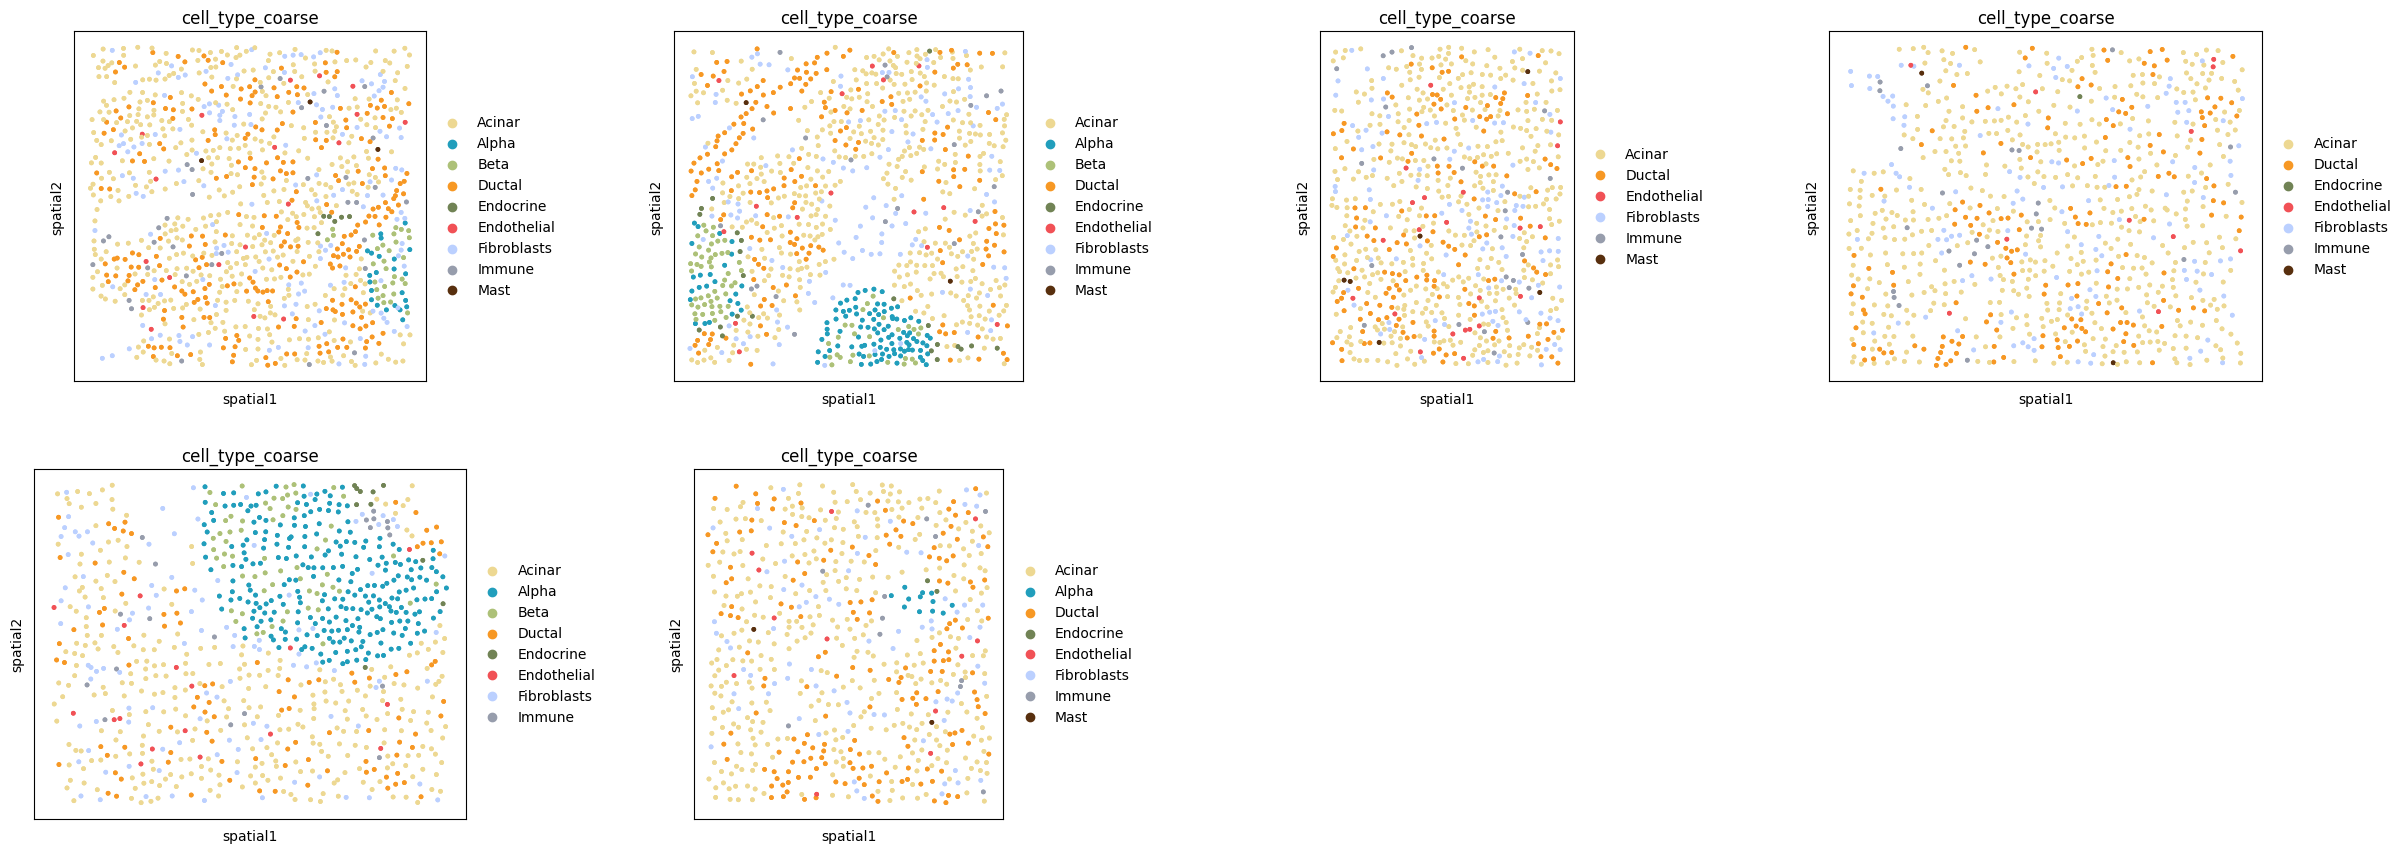

In [77]:
sq.pl.spatial_scatter(
                sub_adata_12,
                color = ['cell_type_coarse'],
                spatial_key = 'spatial',
                shape=None,
                library_key='sliding_window', 
    )

### Interactions strength between cell types

First, we will use the attention matrices to calculate the interaction strength between cells of a class (e.i. cell type).

In [27]:
class_key = 'cell_type_coarse'

In [74]:
def cell_label_attention(sub_adata, obs_csv, attention_matrix_dict, class_key, library_key):
    """Visualizes the normalized attention between cell labels."""
    
    class_names = np.unique(sub_adata.obs[class_key])
    K = len(class_names)
    attn_map = pd.DataFrame(np.zeros((K, K)), index=class_names, columns=class_names)
    attn_occurences = pd.DataFrame(np.zeros((K, K)), index=class_names, columns=class_names)
    for library_id in np.unique(sub_adata.obs[library_key]):
        print(library_id)
        print(np.unique(sub_adata.obs[class_key][sub_adata.obs[library_key]==library_id]))
        # TODO: Incorrect mapping!
        attention_matrix = attention_matrix_dict[library_id]
        filtered_obs_csv = obs_csv[obs_csv['obs_names'].isin(attention_matrix.index)]
        obs_name_to_cell_type = dict(zip(filtered_obs_csv['obs_names'], filtered_obs_csv[class_key]))
        attention_matrix = attention_matrix.rename(index=obs_name_to_cell_type, columns=obs_name_to_cell_type)
        attn_norm = normalized_class_attention(attention_matrix)
        # Add values to attn_map and increment attn_occurences
        attn_map.loc[attn_norm.index, attn_norm.columns] += attn_norm
        attn_occurences.loc[attn_norm.index, attn_norm.columns] += 1

    attn_norm = attn_map/attn_occurences

    return attn_norm

10_0
['Acinar' 'Ductal' 'Endocrine' 'Endothelial' 'Fibroblasts' 'Immune' 'Mast']
10_1
['Acinar' 'Alpha' 'Beta' 'Ductal' 'Endocrine' 'Endothelial' 'Fibroblasts'
 'Immune' 'Mast']
10_2
['Acinar' 'Alpha' 'Beta' 'Ductal' 'Endocrine' 'Endothelial' 'Fibroblasts'
 'Immune' 'Mast']
10_3
['Acinar' 'Alpha' 'Beta' 'Ductal' 'Endocrine' 'Endothelial' 'Fibroblasts'
 'Immune' 'Mast']
10_4
['Acinar' 'Alpha' 'Beta' 'Ductal' 'Endocrine' 'Endothelial' 'Fibroblasts'
 'Immune' 'Mast']
10_5
['Acinar' 'Ductal' 'Endothelial' 'Fibroblasts' 'Immune' 'Mast']


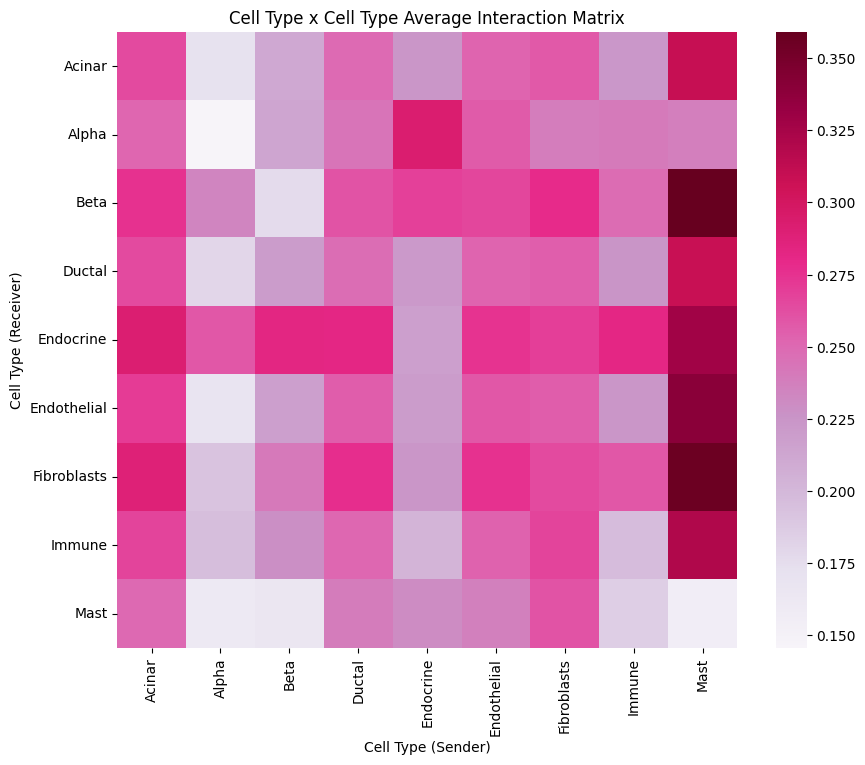

In [94]:
attn_norm_condition_10 = cell_label_attention(sub_adata_10, obs_condition, attention_matrix_dict_condition_10, class_key, library_key = "sliding_window")
plt.figure(figsize=(10, 8))
sns.heatmap(attn_norm_condition_7, cmap = 'PuRd')
plt.title('Cell Type x Cell Type Average Interaction Matrix')
plt.xlabel('Cell Type (Sender)')
plt.ylabel('Cell Type (Receiver)')
plt.savefig(f'/home/icb/francesca.drummer/1-Projects/GT-long-range-niches/figures/pancreas/heat_map_ND-T1D.png')
plt.show()

In [83]:
attn_norm_condition = cell_label_attention(sub_adata, obs_condition, attention_matrix_dict_condition, class_key, library_key = "sliding_window")

12_0
['Acinar' 'Alpha' 'Beta' 'Ductal' 'Endocrine' 'Endothelial' 'Fibroblasts'
 'Immune' 'Mast']
12_1
['Acinar' 'Alpha' 'Beta' 'Ductal' 'Endocrine' 'Endothelial' 'Fibroblasts'
 'Immune' 'Mast']
12_2
['Acinar' 'Ductal' 'Endothelial' 'Fibroblasts' 'Immune' 'Mast']
12_3
['Acinar' 'Ductal' 'Endocrine' 'Endothelial' 'Fibroblasts' 'Immune' 'Mast']
12_4
['Acinar' 'Alpha' 'Beta' 'Ductal' 'Endocrine' 'Endothelial' 'Fibroblasts'
 'Immune']
12_5
['Acinar' 'Alpha' 'Ductal' 'Endocrine' 'Endothelial' 'Fibroblasts'
 'Immune' 'Mast']


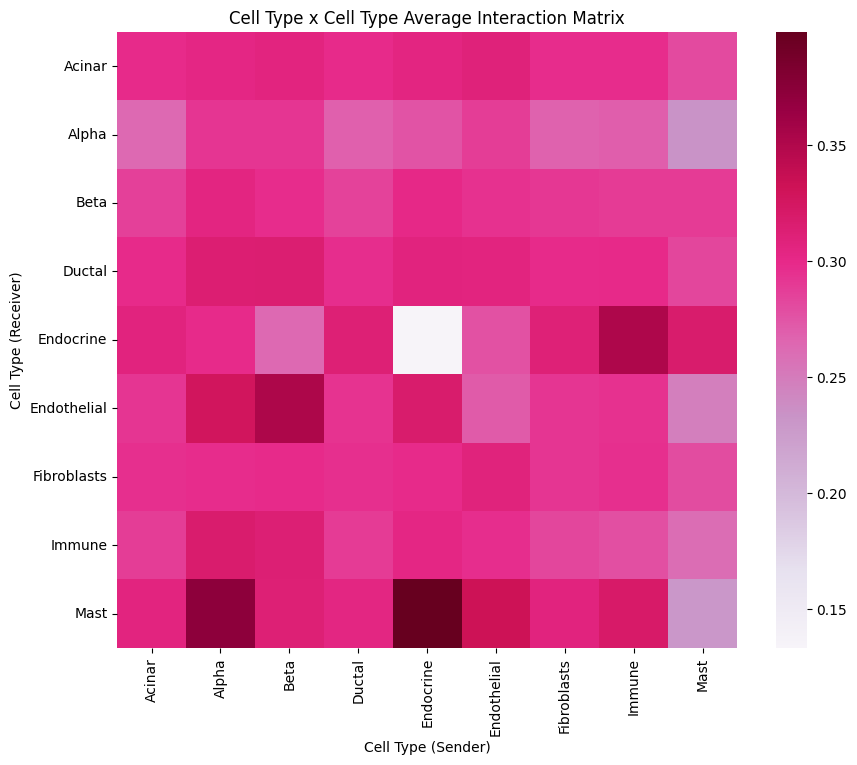

In [89]:
plt.figure(figsize=(10, 8))
sns.heatmap(attn_norm_condition, cmap = 'PuRd')
plt.title('Cell Type x Cell Type Average Interaction Matrix')
plt.xlabel('Cell Type (Sender)')
plt.ylabel('Cell Type (Receiver)')
plt.savefig(f'/home/icb/francesca.drummer/1-Projects/GT-long-range-niches/figures/pancreas/heat_map_ND-T1D.png')
plt.show()

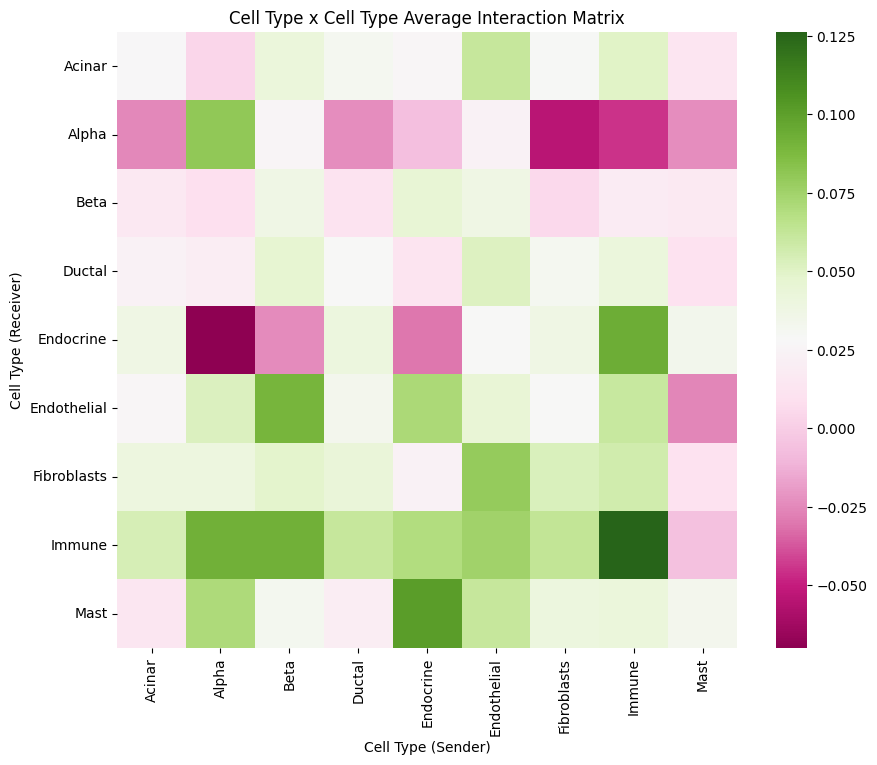

In [98]:
# No Diabetes - T1D
plt.figure(figsize=(10, 8))
sns.heatmap(attn_norm_condition-attn_norm_condition_10, cmap = 'PiYG')
plt.title('Cell Type x Cell Type Average Interaction Matrix')
plt.xlabel('Cell Type (Sender)')
plt.ylabel('Cell Type (Receiver)')
plt.savefig(f'/home/icb/francesca.drummer/1-Projects/GT-long-range-niches/figures/pancreas/heat_map_ND-T1D.png')
plt.show()

In [100]:
attn_norm_ct_12 = cell_label_attention(sub_adata_12, obs_ct, attention_matrix_dict_ct_12, class_key, library_key = "sliding_window")
attn_norm_ct_10 = cell_label_attention(sub_adata_10, obs_ct, attention_matrix_dict_ct_10, class_key, library_key = "sliding_window")

12_0
['Acinar' 'Alpha' 'Beta' 'Ductal' 'Endocrine' 'Endothelial' 'Fibroblasts'
 'Immune' 'Mast']
12_1
['Acinar' 'Alpha' 'Beta' 'Ductal' 'Endocrine' 'Endothelial' 'Fibroblasts'
 'Immune' 'Mast']
12_2
['Acinar' 'Ductal' 'Endothelial' 'Fibroblasts' 'Immune' 'Mast']
12_3
['Acinar' 'Ductal' 'Endocrine' 'Endothelial' 'Fibroblasts' 'Immune' 'Mast']
12_4
['Acinar' 'Alpha' 'Beta' 'Ductal' 'Endocrine' 'Endothelial' 'Fibroblasts'
 'Immune']
12_5
['Acinar' 'Alpha' 'Ductal' 'Endocrine' 'Endothelial' 'Fibroblasts'
 'Immune' 'Mast']
10_0
['Acinar' 'Ductal' 'Endocrine' 'Endothelial' 'Fibroblasts' 'Immune' 'Mast']
10_1
['Acinar' 'Alpha' 'Beta' 'Ductal' 'Endocrine' 'Endothelial' 'Fibroblasts'
 'Immune' 'Mast']
10_2
['Acinar' 'Alpha' 'Beta' 'Ductal' 'Endocrine' 'Endothelial' 'Fibroblasts'
 'Immune' 'Mast']
10_3
['Acinar' 'Alpha' 'Beta' 'Ductal' 'Endocrine' 'Endothelial' 'Fibroblasts'
 'Immune' 'Mast']
10_4
['Acinar' 'Alpha' 'Beta' 'Ductal' 'Endocrine' 'Endothelial' 'Fibroblasts'
 'Immune' 'Mast']
10_5
['

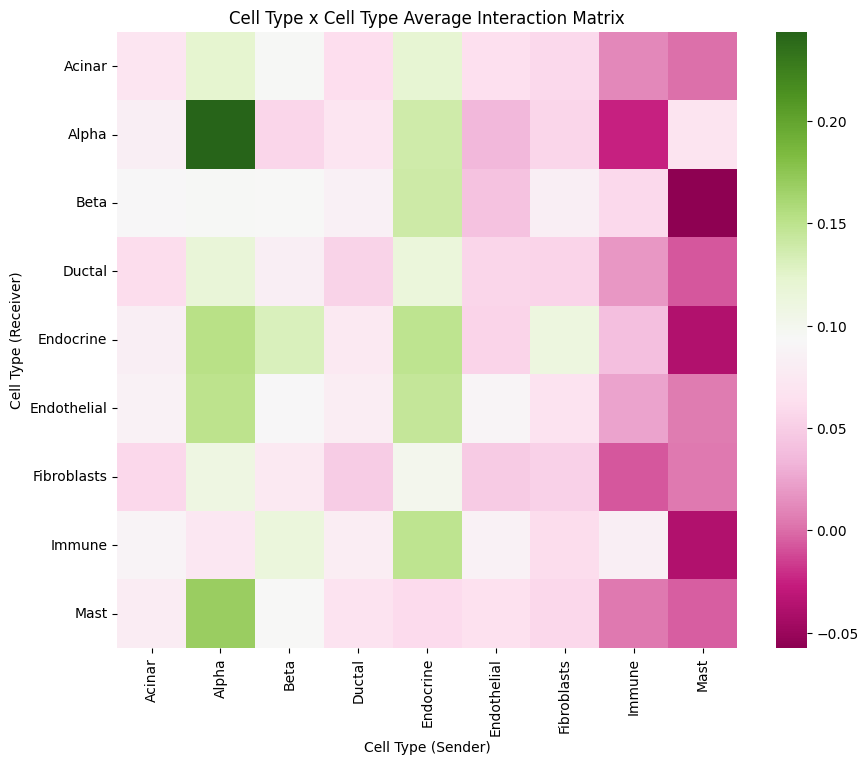

In [101]:
# No Diabetes - T1D
plt.figure(figsize=(10, 8))
sns.heatmap(attn_norm_ct_12-attn_norm_ct_10, cmap = 'PiYG')
plt.title('Cell Type x Cell Type Average Interaction Matrix')
plt.xlabel('Cell Type (Sender)')
plt.ylabel('Cell Type (Receiver)')
plt.savefig(f'/home/icb/francesca.drummer/1-Projects/GT-long-range-niches/figures/pancreas/heat_map_ND-T1D.png')
plt.show()

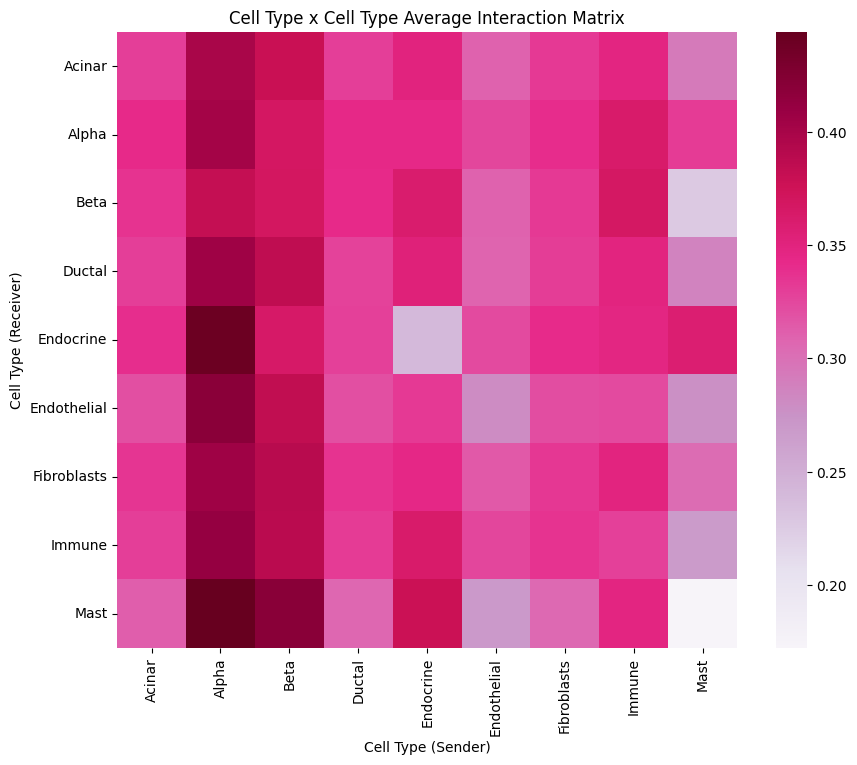

In [90]:
plt.figure(figsize=(10, 8))
sns.heatmap(attn_norm_ct, cmap = 'PuRd')
plt.title('Cell Type x Cell Type Average Interaction Matrix')
plt.xlabel('Cell Type (Sender)')
plt.ylabel('Cell Type (Receiver)')
plt.savefig(f'/home/icb/francesca.drummer/1-Projects/GT-long-range-niches/figures/pancreas/heat_map_ND-T1D.png')
plt.show()

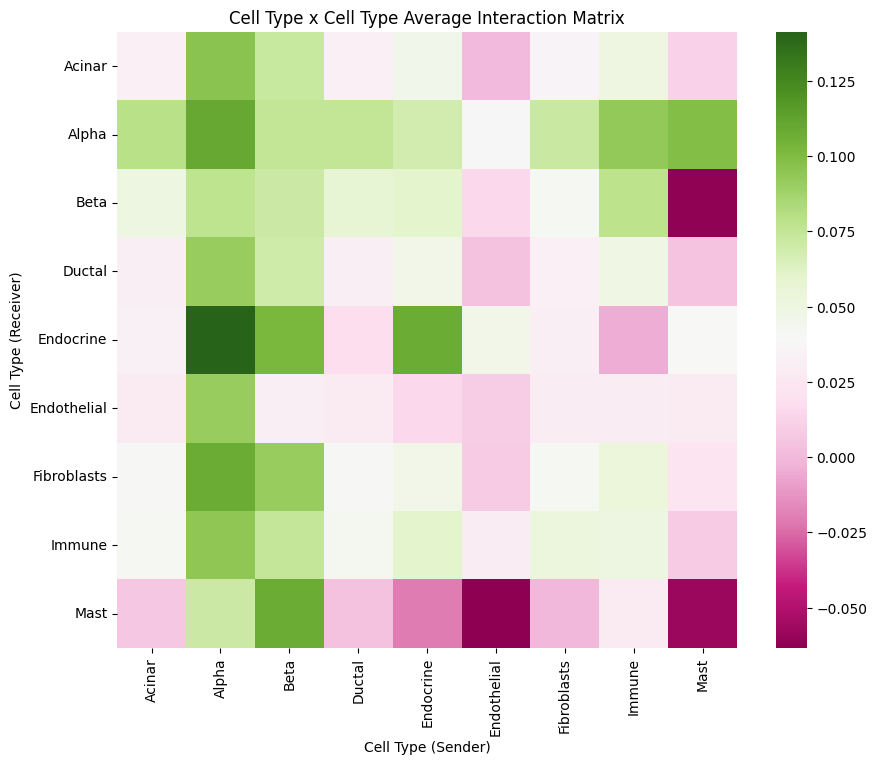

In [88]:
plt.figure(figsize=(10, 8))
sns.heatmap(attn_norm_ct-attn_norm_condition, cmap = 'PiYG')
plt.title('Cell Type x Cell Type Average Interaction Matrix')
plt.xlabel('Cell Type (Sender)')
plt.ylabel('Cell Type (Receiver)')
plt.savefig(f'/home/icb/francesca.drummer/1-Projects/GT-long-range-niches/figures/pancreas/heat_map_ND-T1D.png')
plt.show()

In [ ]:
attn_norm = cell_label_attention(sub_adata, obs_ct, attention_matrix_dict_ct, class_key, library_key = "sliding_window")

### Sender-receiver interaction 

In [16]:
def normalize_attention(attention_matrix, clamp = 0.05):
    np.fill_diagonal(attention_matrix.values, 0)
    
    # Clamp and scale attention matrix
    scores = torch.tensor(attention_matrix.values)
    if clamp:
        q05, q95 = torch.quantile(scores, clamp), torch.quantile(scores, 1-clamp)
        scores = np.clip(scores, a_min=q05, a_max=q95)
    scores = MinMaxScaler(feature_range=(0, 1)).fit_transform(scores)
    return scores

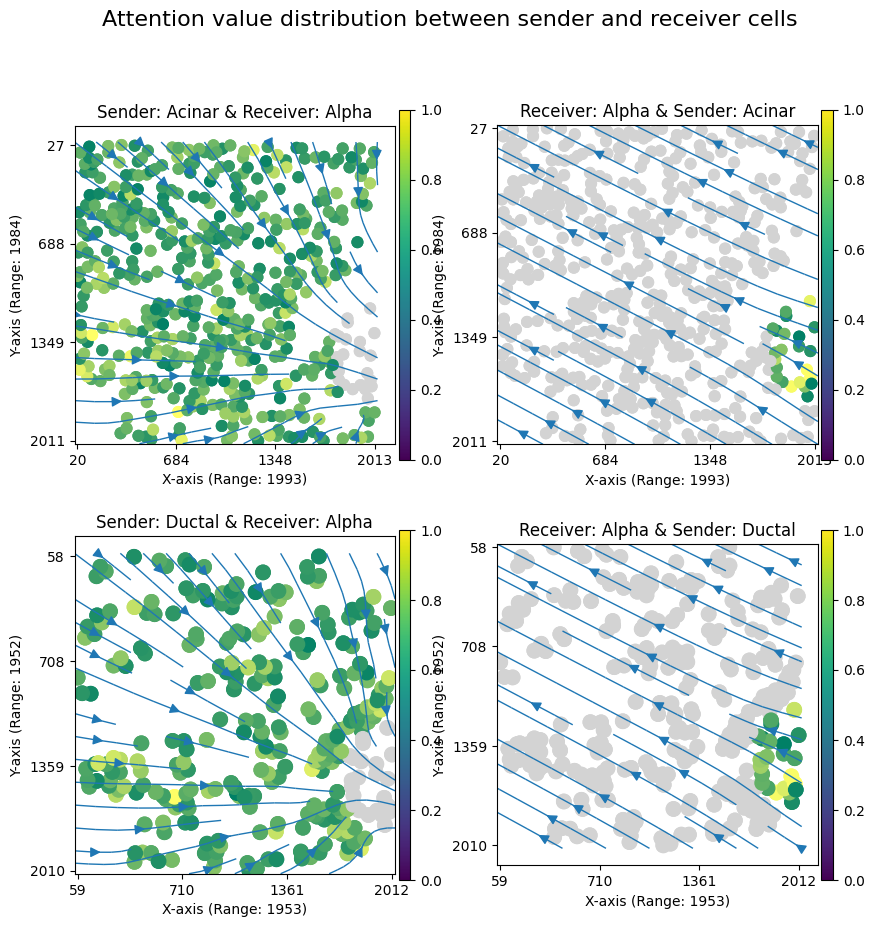

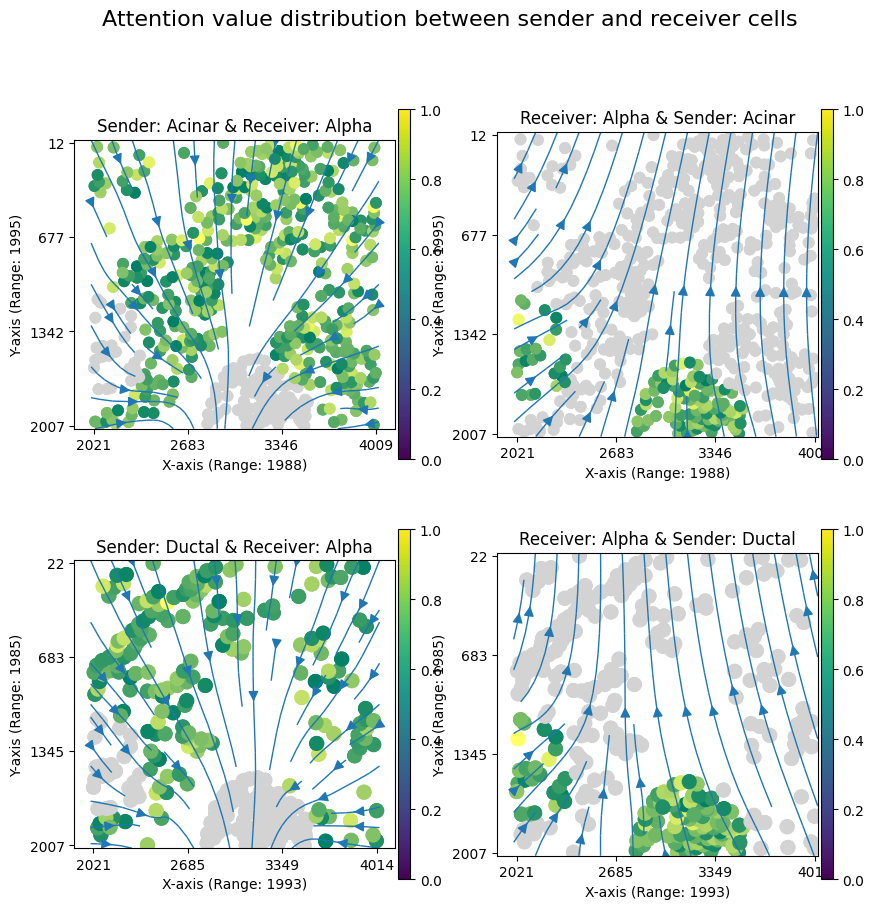

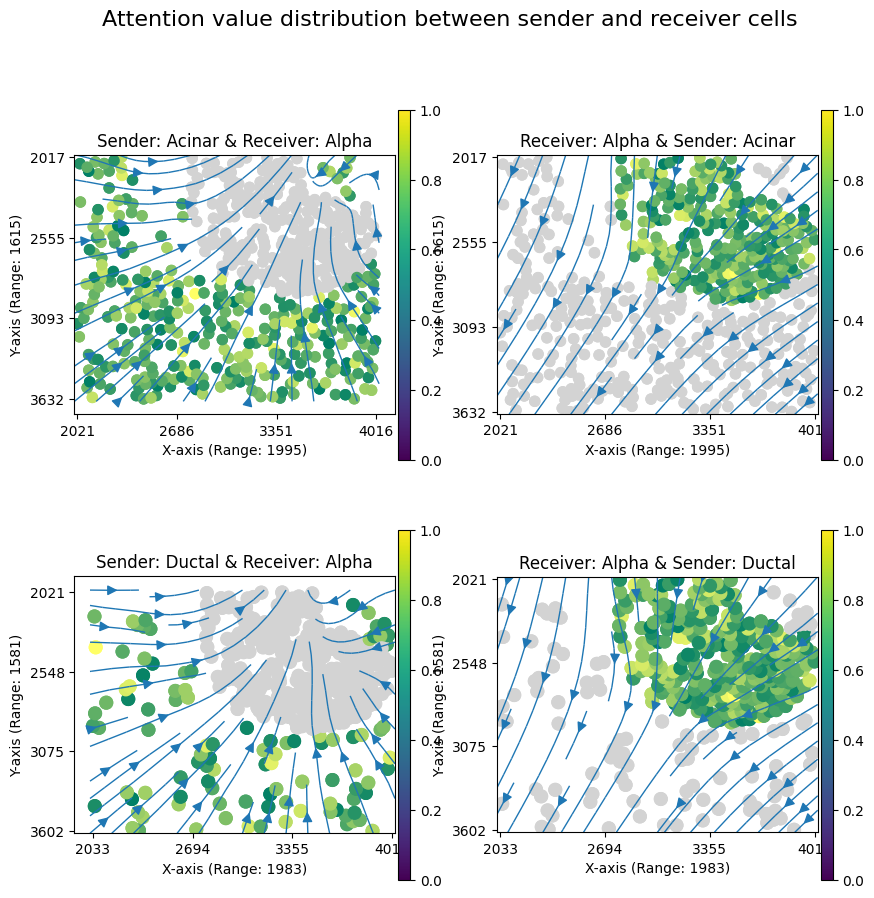

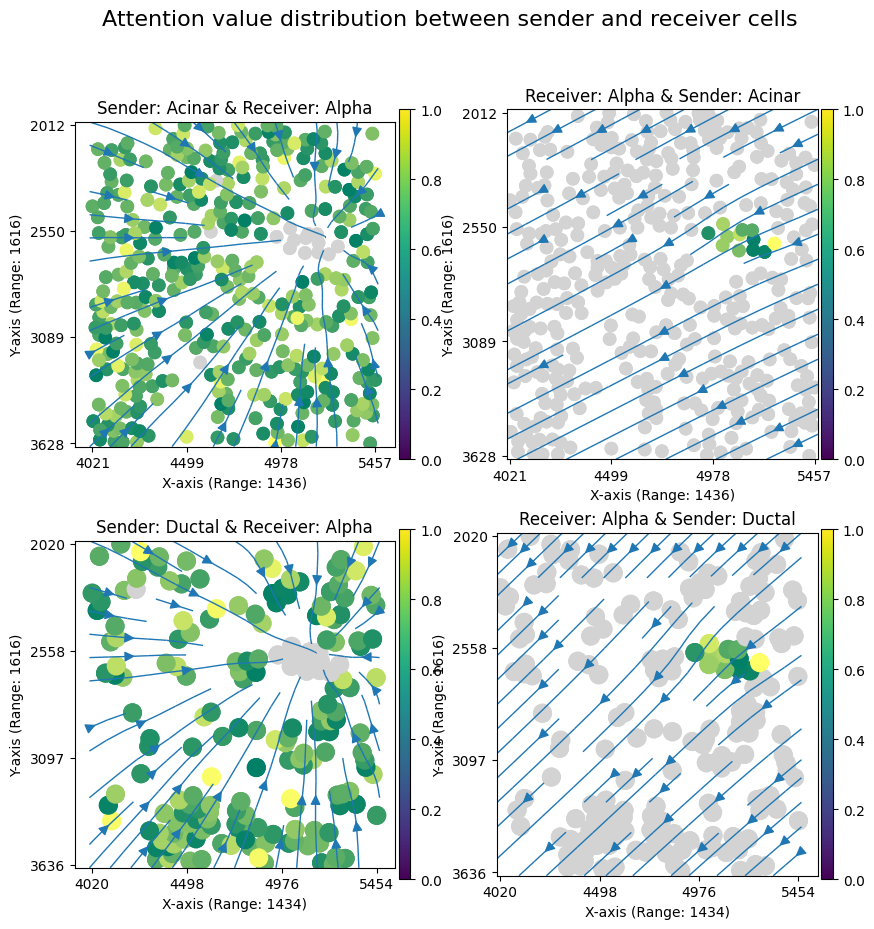

In [14]:
sender = ['Acinar', 'Ductal']
receiver = 'Alpha'
class_name = 'cell_type_coarse'

for sliding_window_id in attention_matrix_dict_condition_12.keys():
    attention_matrix = attention_matrix_dict_condition_12[sliding_window_id]
    val_sub_adata = sub_adata_12[sub_adata_12.obs['sliding_window'] == sliding_window_id]
    val_sub_adata = val_sub_adata[val_sub_adata.obs_names.isin(attention_matrix.index)]
    if receiver in np.unique(val_sub_adata.obs[class_name]):
        attn_norm = normalized_attention(attention_matrix)
        val_sub_adata.obsm['attention_matrix'] = attn_norm
        plot_attention_sender_receiver(val_sub_adata, sender, receiver, cell_type_key = 'cell_type_coarse', attn_matrix_key='attention_matrix', add_streamline = True, discrete_values=True, show_index = True)

In [16]:
cell_type_key = 'cell_type_coarse'

In [101]:
def normalized_class_attention(attention_matrix, clamp: int = 0.05):
    """
    Returns the normalized attention for each class to class in the attention matrix
    Parameters
    ----------
        attention_matrix: PandasDataframe
            Matrix of size NxN with column and row indices belonging to either of K classes
    Returns
    -------
        attn_norm: 
            NxK, where 
    """
    scores = normalized_attention(attention_matrix, clamp)
    attention_matrix = pd.DataFrame(scores, index = attention_matrix.index, columns = attention_matrix.columns)

    class_names = np.unique(attention_matrix.columns)
    print(class_names)

    results = pd.DataFrame(index = attention_matrix.index, columns = class_names)

    for receiver_class in class_names:
        print(receiver_class)
        class_attentions = attention_matrix.loc[:, receiver_class] # N_all x N_receiverClass
        results.loc[:, receiver_class] = class_attentions.mean(axis = 1)
    
    return results
                

In [102]:
class_key = 'cell_type_coarse'
library_key = 'sliding_window'

In [125]:
sub_adata_12.obs_names

Index(['1_12', '2_12', '3_12', '4_12', '5_12', '6_12', '7_12', '8_12', '9_12',
       '10_12',
       ...
       '5219_12', '5220_12', '5221_12', '5222_12', '5223_12', '5224_12',
       '5225_12', '5226_12', '5227_12', '5228_12'],
      dtype='object', length=5208)

In [132]:
sub_adata_12.obs[f'attn_{receiver_class}'] = attn_norm['Acinar']

In [133]:
sub_adata_12.obs[f'attn_{receiver_class}'] 

1_12            NaN
2_12            NaN
3_12            NaN
4_12            NaN
5_12            NaN
             ...   
5224_12    0.425931
5225_12     0.24366
5226_12         NaN
5227_12         NaN
5228_12    0.330421
Name: attn_1996_12, Length: 5208, dtype: object

In [142]:
class_names = np.unique(sub_adata_12.obs[class_key])
K = len(class_names)
for receiver_class in np.unique(sub_adata_12.obs[class_key]):
    sub_adata_12.obs[f'attn_{receiver_class}'] = np.nan
for library_id in np.unique(sub_adata_12.obs[library_key]):
    print(library_id)
    attention_matrix = attention_matrix_dict_condition_12[library_id]
    filtered_obs_csv = obs_condition[obs_condition['obs_names'].isin(attention_matrix.index)]
    obs_name_to_cell_type = dict(zip(filtered_obs_csv['obs_names'], filtered_obs_csv[class_key]))
    #attention_matrix = attention_matrix.rename(index=obs_name_to_cell_type, columns=obs_name_to_cell_type)
    attention_matrix = attention_matrix.rename(columns=obs_name_to_cell_type)
    attn_norm = normalized_class_attention(attention_matrix)
    print(attn_norm)
    # Add values to attn_map and increment attn_occurences
    for receiver_class in class_names:
        sub_adata_12.obs[f'attn_{receiver_class}'] = attn_norm[receiver_class]

12_0
['Acinar' 'Alpha' 'Beta' 'Ductal' 'Endocrine' 'Endothelial' 'Fibroblasts'
 'Immune' 'Mast']
Acinar
Alpha
Beta
Ductal
Endocrine
Endothelial
Fibroblasts
Immune
Mast
           Acinar     Alpha      Beta    Ductal Endocrine Endothelial  \
1996_12  0.177502  0.167238  0.109524  0.186658  0.106834    0.133819   
2005_12    0.1926  0.148031  0.169231  0.201244  0.229575    0.124185   
2008_12  0.143188    0.1857  0.148126  0.161686  0.102496    0.229407   
2018_12  0.550302  0.412378  0.450508  0.518262   0.42879    0.480355   
2019_12  0.185783  0.257324   0.24099  0.187109  0.125631    0.124992   
...           ...       ...       ...       ...       ...         ...   
5217_12  0.462396   0.47516  0.454972  0.468069  0.311506    0.379109   
5222_12  0.264105  0.187345  0.225565  0.268924  0.358109    0.296298   
5224_12  0.425931  0.434397  0.357479   0.42076  0.134958    0.380602   
5225_12   0.24366  0.256598   0.24648  0.237202  0.106811    0.218107   
5228_12  0.330421  0.471827  

KeyError: 'Alpha'

In [145]:
sub_adata_12.obs['attn_Acinar']

1_12            NaN
2_12            NaN
3_12            NaN
4_12            NaN
5_12            NaN
             ...   
5224_12         NaN
5225_12         NaN
5226_12    0.480124
5227_12     0.33668
5228_12         NaN
Name: attn_Acinar, Length: 5208, dtype: object

In [147]:
val_adata = sub_adata_12[sub_adata_12.obs['sliding_window'] == '12_2']
val_adata.obs['attn_Acinar']

2026_12    0.109307
2039_12    0.287209
2040_12    0.300652
2041_12    0.335654
2045_12    0.226219
             ...   
5214_12    0.193568
5220_12    0.422671
5221_12    0.424975
5226_12    0.480124
5227_12     0.33668
Name: attn_Acinar, Length: 766, dtype: object

UFuncTypeError: Cannot cast ufunc 'lstsq_n' input 1 from dtype('O') to dtype('float64') with casting rule 'same_kind'

<Figure size 727.8x480 with 0 Axes>

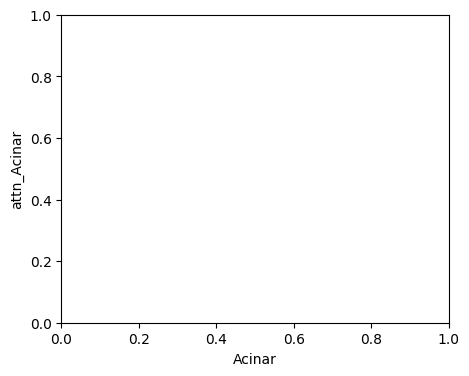

In [149]:

sq.tl.var_by_distance(
                adata=val_adata,
                groups=class_name,
                cluster_key=cell_type_key,
                library_key="sliding_window",
                covariates = ['cell_type_coarse']
)
sq.pl.var_by_distance(
    adata=val_adata,
    design_matrix_key="design_matrix",
    covariate = 'cell_type_coarse',
    var=[f'attn_Acinar'],
    line_palette=['#edd892','#219ebc','#adc178','#f79824','#718355','#f15156','#bbd0ff','#979dac','#582f0e'],
    anchor_key=class_name,
    show_scatter=False,
    figsize=(5, 4),
    order=2
    #regplot_kwargs = {'lowless':False},
)

## Cluster Embeddings

In [92]:
def relative_abundances(adata, group_by, cell_type_key):
    counts = adata.obs.groupby([group_by, cell_type_key]).size().unstack(fill_value=0)
    print(counts)
    relative_abundance = counts.div(counts.sum(axis=1), axis=0)
    return relative_abundance

In [16]:
trans_in_dict_cond_12['12_0'].shape

torch.Size([1000, 1, 128])

In [18]:
trans_out_dict_cond_12['12_0'].shape

torch.Size([1001, 1, 128])

In [78]:
sliding_window_key = '12_4'

In [79]:
val_adata = sub_adata_12[sub_adata_12.obs['sliding_window'] == sliding_window_key]
val_adata

View of AnnData object with n_obs × n_vars = 885 × 979
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.GCG', 'Max.GCG', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'condition', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_NegPrb', 'log1p_total_counts_NegPrb', 'pct_counts_NegPrb', 'n_genes', 'cell_type_coarse', 'niche_label', 'x', 'y', 'globalX', 'globalY', 'sliding_window_1', 'sliding_window_2', 'sliding_window_3', 'sliding_window_4', 'sliding_window', 'split', 'cls'
    uns: 'cell_type_coarse_colors', 'sliding_window_1_colors', 'sliding_window_2_colors', 'spatial', 'spatial_neighbors'
    obsm: 'spatial', 'spatial_fov'
    layers: 'counts'

In [80]:
from anndata import AnnData

emb_in = trans_in_dict_cond_12[sliding_window_key].squeeze(1).detach().numpy()[1:]
emb_out = trans_out_dict_cond_12[sliding_window_key].squeeze(1).detach().numpy()[1:]  # Store embedding in the "transformer_out" layer

adata = AnnData(X=emb_out)

# Step 3: Compute a k-nearest neighbors graph using the embedding from the layer
adata.obsm["X_embedding"] = emb_out  # Temporarily store the embedding in `.obsm` for neighbors
sc.pp.neighbors(adata, n_neighbors=15, use_rep="X_embedding")  # Use this representation

# Step 4: Apply Leiden clustering
sc.tl.leiden(adata, resolution=0.75)  # Adjust resolution as needed

In [81]:
adata

AnnData object with n_obs × n_vars = 885 × 128
    obs: 'leiden'
    uns: 'neighbors', 'leiden'
    obsm: 'X_embedding'
    obsp: 'distances', 'connectivities'

In [97]:
val_adata.obs['cell_type_coarse'].values

['Acinar', 'Acinar', 'Fibroblasts', 'Acinar', 'Acinar', ..., 'Acinar', 'Acinar', 'Fibroblasts', 'Alpha', 'Acinar']
Length: 885
Categories (8, object): ['Acinar', 'Alpha', 'Beta', 'Ductal', 'Endocrine', 'Endothelial', 'Fibroblasts', 'Immune']

In [98]:
adata.obsm['spatial'] = val_adata.obsm['spatial']
adata.obs['cell_type'] = val_adata.obs['cell_type_coarse'].values

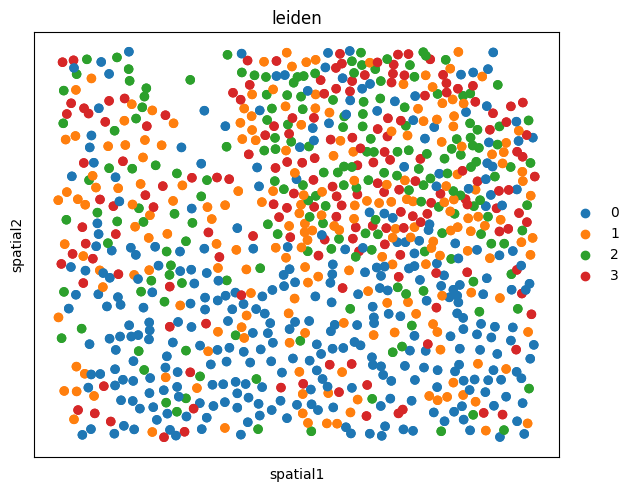

In [89]:
sq.pl.spatial_scatter(
                adata,
                color = ['leiden'],
                spatial_key = 'spatial',
                shape=None,
    )

In [90]:
adata

AnnData object with n_obs × n_vars = 885 × 128
    obs: 'leiden', 'cell_type'
    uns: 'neighbors', 'leiden', 'leiden_colors'
    obsm: 'X_embedding', 'spatial'
    obsp: 'distances', 'connectivities'

In [99]:
adata.obs['cell_type'] 

0           Acinar
1           Acinar
2      Fibroblasts
3           Acinar
4           Acinar
          ...     
880         Acinar
881         Acinar
882    Fibroblasts
883          Alpha
884         Acinar
Name: cell_type, Length: 885, dtype: category
Categories (8, object): ['Acinar', 'Alpha', 'Beta', 'Ductal', 'Endocrine', 'Endothelial', 'Fibroblasts', 'Immune']

In [100]:
relative_abundances(adata, 'leiden', 'cell_type')

cell_type  Acinar  Alpha  Beta  Ductal  Endocrine  Endothelial  Fibroblasts  \
leiden                                                                        
0             173     49     7      34          0           12           42   
1              61     70    14      29          4            1           24   
2              43     82    16      18          3            2           18   
3              36     59    25      19          3            2           20   

cell_type  Immune  
leiden             
0               7  
1               4  
2               4  
3               4  


cell_type,Acinar,Alpha,Beta,Ductal,Endocrine,Endothelial,Fibroblasts,Immune
leiden,,,,,,,,
0,0.533951,0.151235,0.021605,0.104938,0.000000,0.037037,0.129630,0.021605
1,0.294686,0.338164,0.067633,0.140097,0.019324,0.004831,0.115942,0.019324
2,0.231183,0.440860,0.086022,0.096774,0.016129,0.010753,0.096774,0.021505
3,0.214286,0.351190,0.148810,0.113095,0.017857,0.011905,0.119048,0.023810
